<style>
.jp-Cell, .jp-OutputArea, .jp-InputArea, body {
    max-width: 1100px !important;
    margin-left: auto !important;
    margin-right: auto !important;
}
</style>

# Brazilian E-Commerce Market Analysis for Turkish E-commerce Platform

**Student:** Selin Hacıoğlu - GH1045279  
**Program:** MSc Data Science, AI and Digital Business  
**Module:** M504B AI and Applications    
**Instructor:** Dr. Sanjit Kumar Saha     
**University:** GISMA University of Applied Sciences  
**Date:** Jun 2026  
**Dataset URL:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


# 1. Introduction and Business Context

Latin America is one of the fastest-growing digital markets in the world (eMarketer, 2025). Brazil accounts for approximately 40% of online shopping activity in the region. This domination of Brazil makes it a good starting point for companies entering this market (Market Data Forecast, 2026).

This analysis was done for a large Turkish online marketplace that connects thousands of sellers with millions of buyers. The company plans to enter Latin America and needs insights from real data before spending resources. Brazil was picked because shoppers there behave similarly to those in Turkey, for example both markets rely on installment payments and mobile shopping (dLocal, 2023; J.P. Morgan, n.d.).

The data comes from Olist, one of the biggest marketplaces in Brazil, and includes more than 100,000 orders from all 27 states. The analysis has three parts and these steps are outlined below.

**Phase 1 – Market:** Where are customers? How loyal are they? What do they buy? How do they pay?  
**Phase 2 – Operations:** How fast is delivery? What drives satisfaction?   
**Phase 3 – Growth:** Which sellers matter? When to launch?  

# 2. Data Exploration
## 2.1 Setup and Data Loading

Libraries and datasets were loaded for the graphs to be created and calculations to be performed in this section. The same colors are used across all graphs, and a common color scheme and styling function are defined to minimize repetition.

In [345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import squarify

bg_color = "#f5f5f5"
text_color = '#6D6B6B'
accent_red = '#8B1A2B'
accent_blue = '#2C5F7C'
light_grey = '#BDBDBD'
accent_orange = '#E67E22'


def style_ax(ax, hide=['top', 'right']):
    ax.set_facecolor(bg_color)
    for s in hide:
        ax.spines[s].set_visible(False)
    ax.tick_params(colors=text_color)
    ax.xaxis.label.set_color(text_color)
    ax.yaxis.label.set_color(text_color)


customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

## 2.2 Dataset Overview

The table below provides an overview of the size and completeness of each dataset, highlighting which tables need closer examination during preprocessing.

In [346]:
# This cell iterates through all nine datasets and summarizes their row and column counts, missing values, 
# and duplicate records into a summary table. Data reliability is calculated as the percentage of non-missing cells in each dataset.

datasets = {
    'customers': customers, 'orders': orders, 'order_items': order_items,
    'products': products, 'sellers': sellers, 'payments': payments,
    'reviews': reviews, 'geolocation': geolocation, 'category_translation': category_translation
}

rows = {}
columns = {}
missing = {}
duplicates = {}

for name, df in datasets.items():
    rows[name] = len(df)
    columns[name] = df.shape[1]
    missing[name] = df.isnull().sum().sum()
    duplicates[name] = df.duplicated().sum()

overview = pd.DataFrame({
    'Rows': rows,
    'Columns': columns,
    'Missing Values': missing,
    'Duplicates': duplicates
})

total_cells = overview['Rows'] * overview['Columns']
overview['Completeness (%)'] = ((1 - overview['Missing Values'] / total_cells) * 100).round(1)

overview

,Rows,Columns,Missing Values,Duplicates,Completeness (%)
customers,99441,5,0,0,100.0
orders,99441,8,4908,0,99.4
order_items,112650,7,0,0,100.0
products,32951,9,2448,0,99.2
sellers,3095,4,0,0,100.0
payments,103886,5,0,0,100.0
reviews,99224,7,145903,0,79.0
geolocation,1000163,5,0,261831,100.0
category_translation,71,2,0,0,100.0


## 2.3 Data Quality Assessment

The tables with missing values were reviewed in detail.In the orders table, most missing values come from delivery columns. This is expected because some orders were not yet delivered or were cancelled. In the products table, 610 products do not have category names and two have no physical dimensions. In the reviews table, about 59% of reviews have no written comment, but since numerical scores are complete, this does not affect satisfaction analysis.

In [347]:
print("Missing Values - Orders Table:")
print(orders.isnull().sum())
print("\nMissing Values - Products Table:")
print(products.isnull().sum())
print("\nMissing Values - Reviews Table:")
print(reviews.isnull().sum())

Missing Values - Orders Table:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values - Products Table:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Missing Values - Reviews Table:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


The numbers above are interesting because they show that most customers only buy once, and some customers use more than one payment method for a single order. Both of these patterns are important for understanding customer behavior later in the analysis.

## 2.4 Data Preprocessing

The dataset covers all 27 states of Brazil. In addition, it includes 99,441 orders with 112,650 order items. There are 96,096 different customers. About 3,345 of them bought more than once. Also, there are 103,886 payment records for 99,441 orders, which means some customers used more than one way to pay.

To keep the original data safe, all preprocessing was done on copies. The main steps were: Firstly date columns were changed to datetime format. Product categories were translated from Portuguese to English. 623 products that had no category were labeled as "unknown." For the two products with missing dimensions, the median was used to fill in the values. Finally, the geolocation table's 261,831 duplicate rows were deleted.

In [348]:
# To protect the original data, copies are created. Date columns are converted to datetime format. 
# Product categories are translated to English. Missing dimensions are filled with median values. 
# Duplicate rows in the geolocation table are removed


orders = orders.copy()
reviews = reviews.copy()
products = products.copy()
geolocation = geolocation.copy()


date_column = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_column:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

dimension_column = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dimension_column:
    products[col] = products[col].fillna(products[col].median())

geo_cleaning = len(geolocation)
geolocation = geolocation.drop_duplicates()


print("Preprocessing completed.")
print(f"Date range: {orders['order_purchase_timestamp'].min().date()} to {orders['order_purchase_timestamp'].max().date()}")
print(f"Product categories: {products['product_category_name_english'].nunique()}")
print(f"Geolocation duplicates removed: {geo_cleaning - len(geolocation):,}")

Preprocessing completed.
Date range: 2016-09-04 to 2018-10-17
Product categories: 72
Geolocation duplicates removed: 261,831


## 2.5 Data Preparation for Analysis

After preprocessing, tables were merged into a master table combining orders, customers, products, and order items. State-level aggregations and a customer loyalty classification (one-time vs. repeat) were also prepared. Filtered "delivered" table was created for delivery focused analyses.

In [349]:
# Four tables are merged into one using shared keys. Customers are counted and revenue is summed per state.
# The label "Repeat" or "One-Time" is applied to each customer according to the number of orders they place. 
# For delivered orders, a different table with delivery time predictions is made.

merged_table = orders.merge(customers, on='customer_id')
merged_table = merged_table.merge(order_items, on='order_id')
merged_table = merged_table.merge(products, on='product_id')

state_summary = merged_table.groupby('customer_state').agg(
    customer_count=('customer_unique_id', 'nunique'),
    total_revenue=('price', 'sum')
).sort_values('total_revenue', ascending=False)

customer_summary = merged_table.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    total_spent=('price', 'sum')
).reset_index()

customer_summary['customer_type'] = customer_summary['order_count'].apply(
    lambda x: 'Repeat' if x > 1 else 'One-Time'
)

delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['on_time'] = delivered['delay_days'] <= 0

print(f"Merged table: {len(merged_table):,} rows")
print(f"Unique customers: {merged_table['customer_unique_id'].nunique():,}")
print(f"One-Time: {(customer_summary['customer_type']=='One-Time').sum():,}")
print(f"Repeat: {(customer_summary['customer_type']=='Repeat').sum():,}")

Merged table: 112,650 rows
Unique customers: 95,420
One-Time: 92,507
Repeat: 2,913


# 3. Exploratory Data Analysis

### Phase 1: Understanding the Market

#### 3.1 In which states are customers and revenue concentrated?

Knowing where customers are and where revenue comes from helps choose where to launch first, how to allocate marketing budget, and where to invest in logistics.

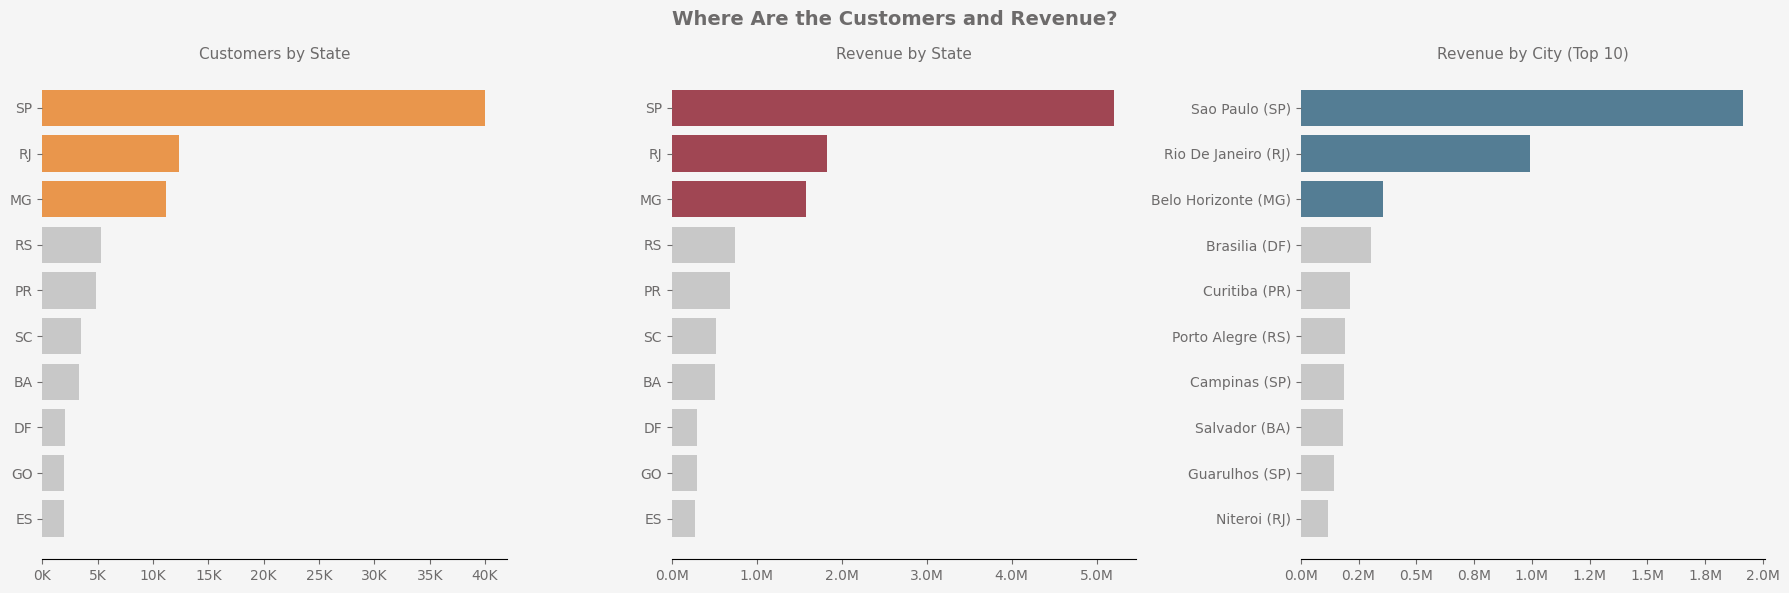

In [350]:

# The top 10 states by revenue are selected. Sales are also grouped by city. 
# Three horizontal bar charts are placed side by side. FuncFormatter shortens large numbers like "15K" or "2.1M" for readability.

top10_states = state_summary.head(10)

city_revenue = merged_table.groupby(['customer_city', 'customer_state'])['price'].sum()
city_revenue = city_revenue.sort_values(ascending=False).head(10)
city_labels = [f"{city.title()} ({state})" for city, state in city_revenue.index]

top3_colors = [accent_red]*3 + [light_grey]*7

fig, (customer_chart, revenue_chart, city_chart) = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(bg_color)


customer_chart.barh(top10_states.index, top10_states['customer_count'], color=[accent_orange]*3 + [light_grey]*7, alpha=0.8)
customer_chart.invert_yaxis()
customer_chart.set_title('Customers by State', fontsize=11, color=text_color)
customer_chart.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
style_ax(customer_chart, hide=['top', 'right', 'left'])


revenue_chart.barh(top10_states.index, top10_states['total_revenue'], color=top3_colors, alpha=0.8)
revenue_chart.invert_yaxis()
revenue_chart.set_title('Revenue by State', fontsize=11, color=text_color)
revenue_chart.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
style_ax(revenue_chart, hide=['top', 'right', 'left'])


city_chart.barh(city_labels, city_revenue.values, color=[accent_blue]*3 + [light_grey]*7, alpha=0.8)
city_chart.invert_yaxis()
city_chart.set_title('Revenue by City (Top 10)', fontsize=11, color=text_color)
city_chart.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
style_ax(city_chart, hide=['top', 'right', 'left'])

fig.suptitle('Where Are the Customers and Revenue?', fontsize=14, fontweight='bold', y=0.98, color=text_color)
plt.tight_layout()
plt.show()

To show the distribution of customers and revenue ,horizontal bar charts were chosen. Because they make it easy to compare states side by side and read long labels. São Paulo is clearly the biggest market in both customer count and revenue. Rio de Janeiro comes second but with roughly one-third of SP's numbers. At the city level, São Paulo alone brings in more revenue than the next nine cities combined. This means the company should focus on the Southeast region first, starting with SP.

#### 3.2 How loyal are customers and how does spending differ?

It is usually cheaper to keep current customers than to attract new ones. Here, we look at how many customers came back for a second purchase and how their spending compares to one-time buyers.

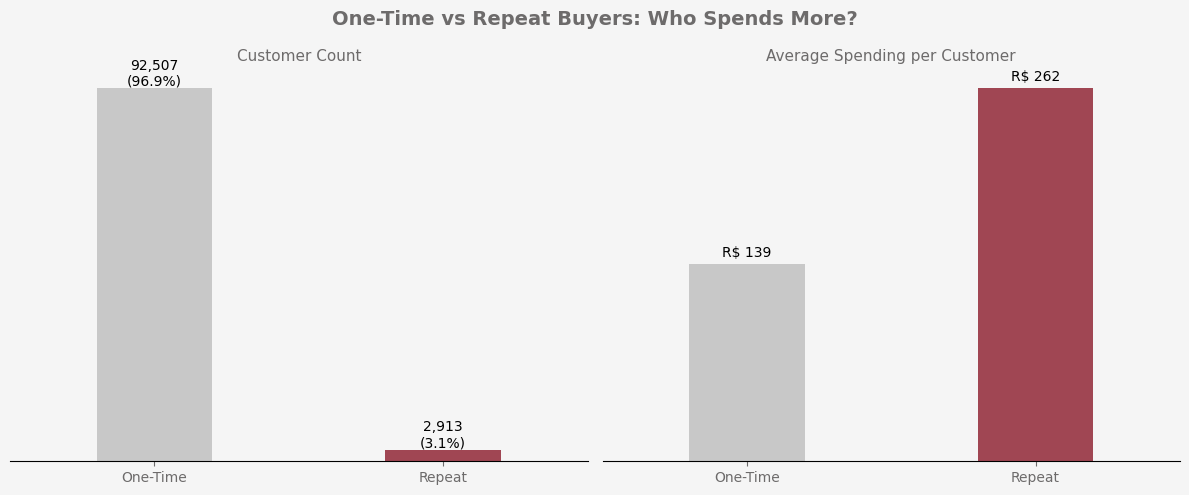

In [351]:
# Customers are grouped by type to count them and calculate average spending.
# Two bar charts are placed side by side with text labels on top of each bar.

loyalty_summary = customer_summary.groupby('customer_type').agg(
    customers=('customer_unique_id', 'count'),
    avg_spent=('total_spent', 'mean')
)
total_customers = loyalty_summary['customers'].sum()

colors = [light_grey, accent_red]

fig, (count_chart, spending_chart) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(bg_color)


count_bars = count_chart.bar(loyalty_summary.index, loyalty_summary['customers'], color=colors, width=0.4, alpha=0.8)
count_chart.set_title('Customer Count', fontsize=11, color=text_color)
for bar, val in zip(count_bars, loyalty_summary['customers']):
    count_chart.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                     f'{val:,}\n({val/total_customers*100:.1f}%)', ha='center', fontsize=10)
style_ax(count_chart, hide=['top', 'right', 'left'])
count_chart.set_yticks([])
count_chart.set_xlim(-0.5, 1.5)


spending_bars = spending_chart.bar(loyalty_summary.index, loyalty_summary['avg_spent'], color=colors, width=0.4, alpha=0.8)
spending_chart.set_title('Average Spending per Customer', fontsize=11, color=text_color)
for bar, val in zip(spending_bars, loyalty_summary['avg_spent']):
    spending_chart.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        f'R$ {val:,.0f}', ha='center', fontsize=10)
style_ax(spending_chart, hide=['top', 'right', 'left'])
spending_chart.set_yticks([])
spending_chart.set_xlim(-0.5, 1.5)

fig.suptitle('One-Time vs Repeat Buyers: Who Spends More?', fontsize=14, fontweight='bold', y=0.98, color=text_color)
plt.tight_layout()
plt.show()

To show the size difference between two groups,  bar chart was used. Because it has a clean and easily separable structure. 96.9% of customers bought only once. But the ones who come back spend almost two times more. The platform is good at getting new buyers, but not at keeping them. A loyalty program in SP could help with this.

#### 3.3 Which product categories generate the most revenue and demand?

After determining where customers are located and what kind of customers they are (loyal or not), the next step is to find out what they purchase. This helps, first and foremost, in deciding which products to offer and which salespeople to hire.

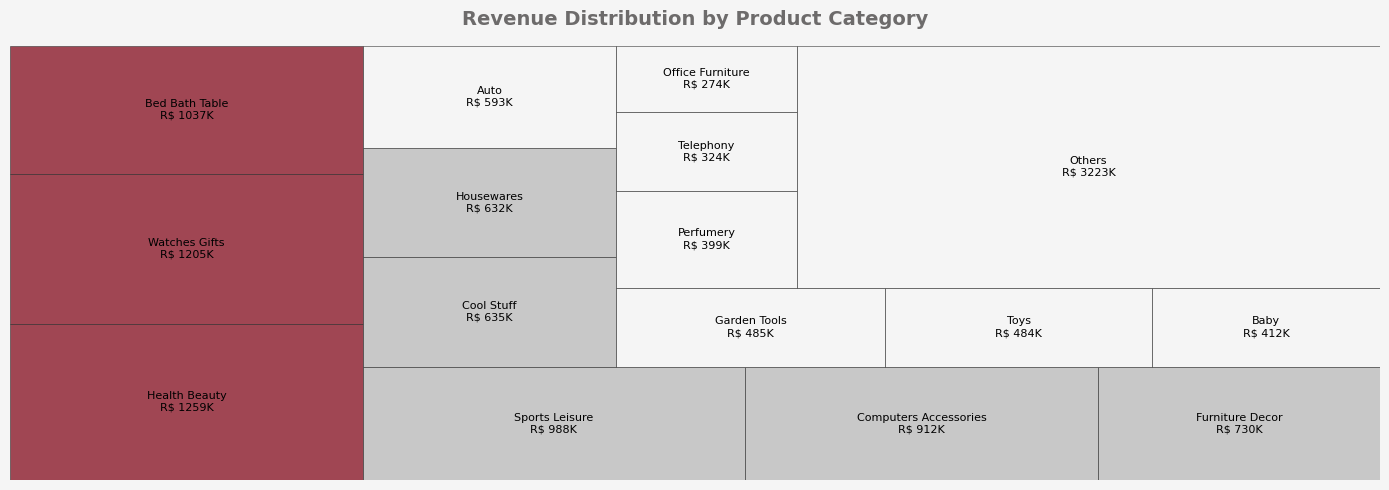

In [352]:
# Products are grouped by category to count orders, total revenue, and average price. 
# Categories outside the top 15 are combined as "others". The treemap shows each category as a box sized by its revenue.

category_stats = merged_table.groupby('product_category_name_english').agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean')
).sort_values('total_revenue', ascending=False)

top15_categories = category_stats.head(15)
others_revenue = category_stats.iloc[15:]['total_revenue'].sum()

treemap_data = pd.concat([top15_categories['total_revenue'], pd.Series({'others': others_revenue})])
treemap_labels = [f"{name.replace('_', ' ').title()}\nR$ {val/1000:.0f}K" for name, val in treemap_data.items()]
colors = [accent_red]*3 + [light_grey]*5 + [bg_color]*9


fig, treemap_chart = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(bg_color)
treemap_chart.set_facecolor(bg_color)

squarify.plot(sizes=treemap_data.values, label=treemap_labels, color=colors,
              alpha=0.8, text_kwargs={'fontsize': 8}, ax=treemap_chart,
              edgecolor='#333333', linewidth=0.5)

treemap_chart.set_title('Revenue Distribution by Product Category',
                         fontsize=14, fontweight='bold', pad=15, color=text_color)
treemap_chart.set_xticks([])
treemap_chart.set_yticks([])
for spine in treemap_chart.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

A treemap was used here because it shows both the ranking and the size difference between categories in one view. The top three are Health Beauty, Watches Gifts, and Bed Bath Table. The rest are small on their own, but together they still cover a large part of total sales.

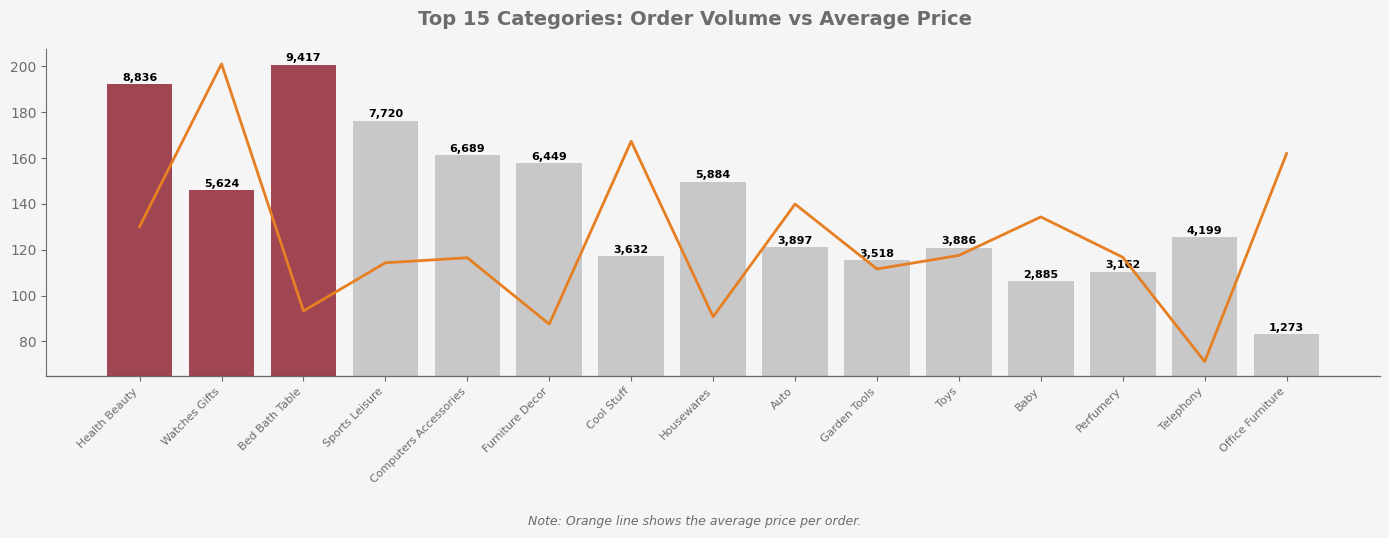

In [353]:
# bar() draws the order counts for each category. .twinx() creates a second y-axis on the same chart so the orange price
# line can use a different scale without messing up the bars. Spines are hidden manually here because twinx() creates
# two overlapping axes and style_ax() cannot handle both at once.

fig, volume_chart = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(bg_color)
volume_chart.set_facecolor(bg_color)


order_bars = volume_chart.bar(range(len(top15_categories)), top15_categories['order_count'],
                               color=[accent_red]*3 + [light_grey]*12, alpha=0.8)

for i, val in enumerate(top15_categories['order_count']):
    volume_chart.text(i, val + 100, f'{val:,}', ha='center', fontsize=8, fontweight='bold')

volume_chart.set_yticks([])
volume_chart.set_xticks(range(len(top15_categories)))
volume_chart.set_xticklabels([name.replace('_', ' ').title() for name in top15_categories.index],
                              rotation=45, ha='right', fontsize=8)


price_line = volume_chart.twinx()
price_line.plot(range(len(top15_categories)), top15_categories['avg_price'],
                color=accent_orange, linewidth=2)
price_line.yaxis.set_label_position('left')
price_line.yaxis.tick_left()

volume_chart.spines[['top', 'right']].set_visible(False)
price_line.spines[['left', 'top', 'right']].set_visible(False)
price_line.spines['bottom'].set_color(text_color)
volume_chart.tick_params(axis='x', colors=text_color)
price_line.tick_params(axis='y', colors=text_color)
volume_chart.spines['left'].set_color(text_color)

fig.suptitle('Top 15 Categories: Order Volume vs Average Price',
             fontsize=14, fontweight='bold', y=0.98, color=text_color)
plt.tight_layout()

fig.text(0.5, -0.05, 'Note: Orange line shows the average price per order.',
         ha='center', fontsize=9, fontstyle='italic', color=text_color)

plt.show()

A dual-axis chart was used here to compare order volume and average price in one view. Bed Bath Table and Health Beauty have the most orders and their prices are reasonable. Watches Gifts has fewer orders but a higher average price, which makes it a premium category.

#### 3.4 What are the main payment methods and how common is installment usage?

Before entering a market, it is important to know how customers make payments. In this section, the common payment methods and the scope of installment payments are examined.

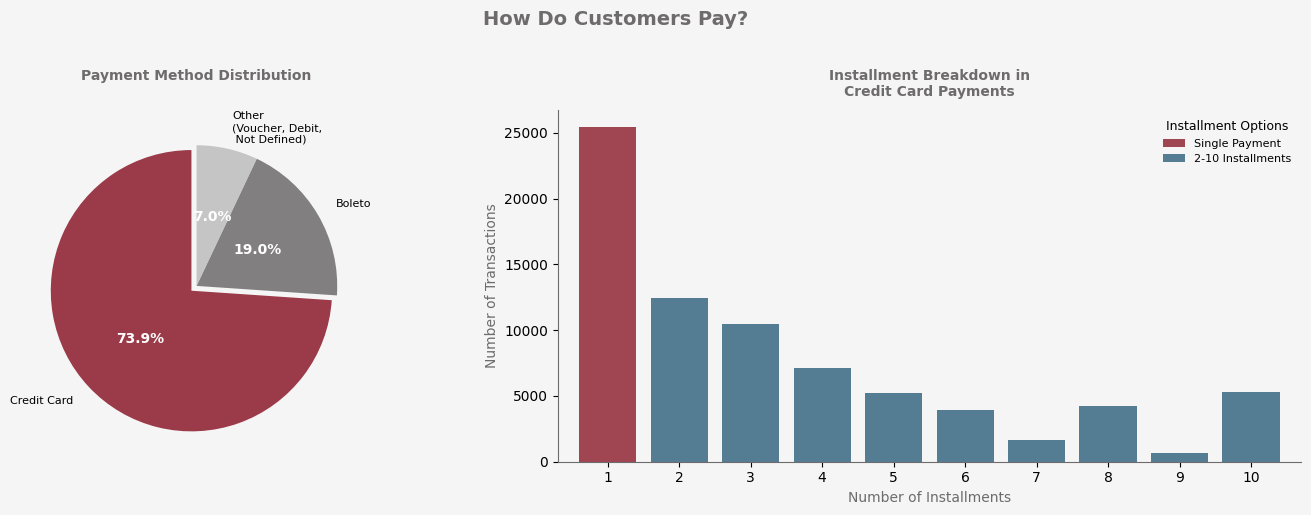

In [354]:
# With ".value_counts()", it counts how many times each payment type appears. ".get()" take out specific values 
# from the result and adds the small ones together into "Other". Boolean indexing filters only the credit card payments,
#  and ".sort_index()" sorts installments from 1 to 10. ".pie()" draws the payment split and ".bar()" shows the installment breakdown.
#  "Patch()" generates legend items so the colors are explained clearly.

payment_counts = payments['payment_type'].value_counts()
main_payments = pd.Series({
    'Credit Card': payment_counts.get('credit_card', 0),
    'Boleto': payment_counts.get('boleto', 0),
    'Other': payment_counts.get('voucher', 0) + payment_counts.get('debit_card', 0) + payment_counts.get('not_defined', 0)
})

credit_card_payments = payments[(payments['payment_type'] == 'credit_card') & (payments['payment_installments'] > 0)]
installment_counts = credit_card_payments['payment_installments'].value_counts().sort_index()
installment_counts = installment_counts[installment_counts.index <= 10]

fig, (payment_pie, installment_chart) = plt.subplots(1, 2, figsize=(14, 5),
                                                      gridspec_kw={'width_ratios': [0.5, 0.7]})
fig.patch.set_facecolor(bg_color)
payment_pie.set_facecolor(bg_color)
installment_chart.set_facecolor(bg_color)

fig.suptitle('How Do Customers Pay?', fontsize=14, fontweight='bold', y=1.02, color=text_color)


wedges, texts, autotexts = payment_pie.pie(
    main_payments.values,
    labels=['Credit Card', 'Boleto', 'Other\n(Voucher, Debit,\n Not Defined)'],
    autopct='%1.1f%%', colors=[accent_red, text_color, light_grey],
    pctdistance=0.5, labeldistance=1.15,
    startangle=90, explode=[0.05, 0, 0],
    wedgeprops=dict(alpha=0.85), textprops=dict(fontsize=8))
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
    t.set_color('white')
payment_pie.set_title('Payment Method Distribution\n', fontsize=10, fontweight='bold', pad=10, color=text_color)


installment_colors = [accent_red if x == 1 else accent_blue for x in installment_counts.index]
installment_chart.bar(installment_counts.index, installment_counts.values,
                      color=installment_colors, alpha=0.8)
installment_chart.set_xlabel('Number of Installments')
installment_chart.xaxis.label.set_color(text_color)
installment_chart.set_ylabel('Number of Transactions')
installment_chart.yaxis.label.set_color(text_color)
installment_chart.set_xticks(range(1, 11))
installment_chart.set_xlim(0.3, 10.7)
installment_chart.spines[['top', 'right']].set_visible(False)
installment_chart.spines['left'].set_color(text_color)
installment_chart.spines['bottom'].set_color(text_color)
installment_chart.set_title('Installment Breakdown in\nCredit Card Payments',
                             fontsize=10, fontweight='bold', pad=10, color=text_color)

installment_chart.legend(handles=[
    Patch(facecolor=accent_red, alpha=0.8, label='Single Payment'),
    Patch(facecolor=accent_blue, alpha=0.8, label='2-10 Installments')
], loc='upper right', fontsize=8, framealpha=0.9, facecolor=bg_color,
   edgecolor=bg_color, title='Installment Options', title_fontsize=9)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()

To show the share of each option in the total, a pie chart was chosen. Because it enables us to clearly visualize percentages in our minds. To show how installments are distributed across different counts, a bar chart was used, and we can clearly see the distribution. Most customers use credit cards, about 74% of all payments. Boleto, a local payment slip in Brazil, comes second at around 19%. When we look closer at credit card users, we notice that only 33% pay at once. The rest split their payments into 2 to 10 installments. This tells us the platform should support installments and offer Boleto from the start.

### Phase 2: Operational Performance

#### 3.5 How does delivery performance vary across regions?

To plan logistics, the company needs to know how fast deliveries are and how reliable they are in different parts of Brazil.

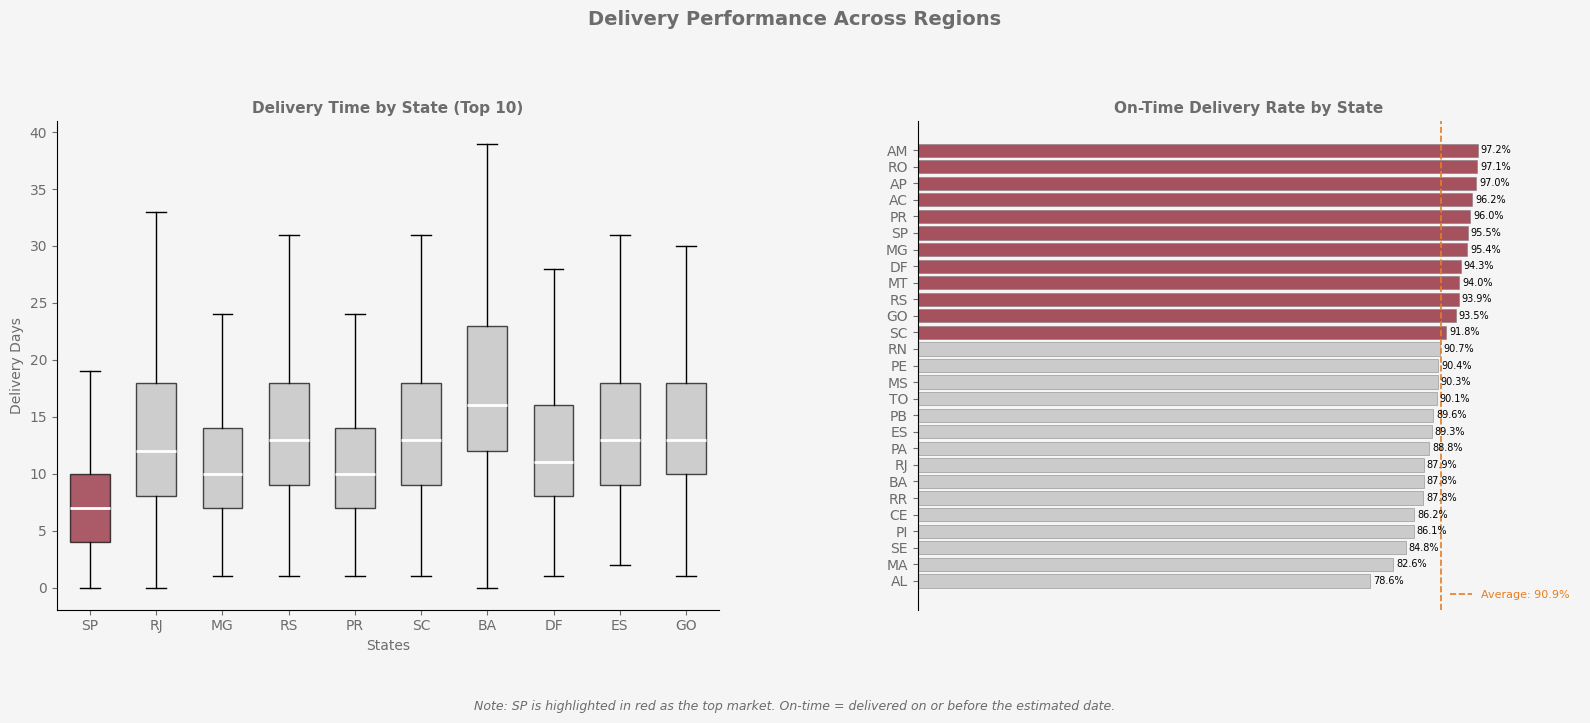

In [355]:
# For returning top 10 states, ".value_counts().head(10)" is used." .mean()" gives the on-time rate 
# and .mul(100) makes it a percentage. .boxplot() shows the range of delivery days per state, the box is where most orders fall. 
# ".axvline()" draws a dashed average line so it is easy to spot which states are faster or slower than the rest.

delivery_data = delivered.merge(customers, on='customer_id')

top10_delivery_states = delivery_data['customer_state'].value_counts().head(10).index

on_time_by_state = delivery_data.groupby('customer_state')['on_time'].mean().mul(100).sort_values()
average_on_time = on_time_by_state.mean()

fig, (boxplot_chart, ontime_chart) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(bg_color)
fig.suptitle('Delivery Performance Across Regions', fontsize=14, fontweight='bold', color=text_color)

state_delivery_days = [delivery_data[delivery_data['customer_state'] == s]['delivery_days'].dropna()
                       for s in top10_delivery_states]

bp = boxplot_chart.boxplot(state_delivery_days, labels=top10_delivery_states,
                           patch_artist=True, showfliers=False, widths=0.6)

for box in bp['boxes']:
    box.set_facecolor(light_grey)
    box.set_alpha(0.7)
bp['boxes'][0].set_facecolor(accent_red)

for m in bp['medians']:
    m.set_color('white')
    m.set_linewidth(2)

style_ax(boxplot_chart)
boxplot_chart.set_xlabel('States')
boxplot_chart.set_ylabel('Delivery Days')
boxplot_chart.set_title('Delivery Time by State (Top 10)', fontsize=11, fontweight='bold', color=text_color)


colors = [light_grey if v < average_on_time else accent_red for v in on_time_by_state]

ontime_chart.barh(on_time_by_state.index, on_time_by_state.values,
                  color=colors, alpha=0.75, edgecolor=text_color, linewidth=0.4)

for state, val in on_time_by_state.items():
    ontime_chart.text(val + 0.5, state, f'{val:.1f}%', va='center', fontsize=7)

ontime_chart.set_xlim(0, 115)
ontime_chart.set_xticks([])
ontime_chart.axvline(average_on_time, color=accent_orange, linestyle='--', linewidth=1.2,
                     label=f'Average: {average_on_time:.1f}%')
ontime_chart.legend(fontsize=8, framealpha=0, labelcolor=accent_orange)
style_ax(ontime_chart, hide=['top', 'right', 'bottom'])
ontime_chart.set_title('On-Time Delivery Rate by State', fontsize=11, fontweight='bold', color=text_color)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.subplots_adjust(wspace=0.3)

fig.text(0.5, -0.02, 'Note: SP is highlighted in red as the top market. On-time = delivered on or before the estimated date.',
         ha='center', fontsize=9, fontstyle='italic', color=text_color)

plt.show()

To show especially the spread and median of delivery days, not just the average, a boxplot was the first option to come to mind. The other chart is a horizontal bar. It was chosen because the chart makes it easy to compare on-time rates across all 27 states at once. São Paulo is the state with the fastest delivery, with a median of about 7 days and consistency. The reason for this is likely that most of the sellers are located there. In the northern and northeastern states, the median rises to 15-25 days. On-time delivery rates also show the same situation: SP, PR, and MG are above 90%, while distant states are below 85%. This also indicates that the warehouse location should be close to the southeast.

#### 3.6 What are the freight cost dynamics and is free shipping possible?

Shipping cost is something customers care a lot about. Looking at the relationship between product weight, order value, and freight cost helps that decide if and where a free shipping threshold makes sense.

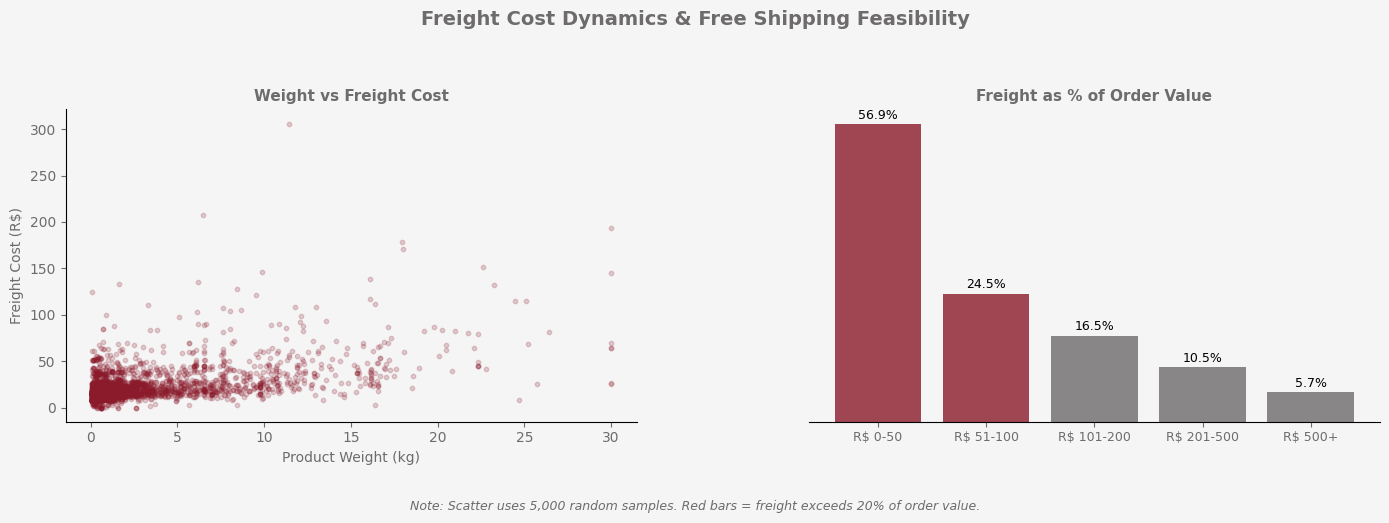

In [356]:
# Rows with missing value were removed. Prices were divided into ranges with using pd.cut().
#  The scatter plot was cleaned up by sampling 5,000 random rows.

freight_data = order_items.merge(products, on='product_id').dropna(subset=['product_weight_g', 'freight_value', 'price'])
freight_data['freight_ratio'] = freight_data['freight_value'] / freight_data['price'] * 100
freight_data['price_range'] = pd.cut(freight_data['price'], bins=[0, 50, 100, 200, 500, 10000],
                                      labels=['0-50', '51-100', '101-200', '201-500', '500+'])

freight_sample = freight_data.sample(5000, random_state=42)
ratio_by_price = freight_data.groupby('price_range', observed=True)['freight_ratio'].mean()


fig, (scatter_chart, ratio_chart) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(bg_color)
fig.suptitle('Freight Cost Dynamics & Free Shipping Feasibility',
             fontsize=14, fontweight='bold', color=text_color)


scatter_chart.scatter(freight_sample['product_weight_g'] / 1000, freight_sample['freight_value'],
                      c=accent_red, alpha=0.2, s=10)
style_ax(scatter_chart)
scatter_chart.set_xlabel('Product Weight (kg)')
scatter_chart.set_ylabel('Freight Cost (R$)')
scatter_chart.set_title('Weight vs Freight Cost', fontsize=11, fontweight='bold', color=text_color)


colors = [accent_red if v > 20 else text_color for v in ratio_by_price]
ratio_chart.bar(range(len(ratio_by_price)), ratio_by_price.values, color=colors, alpha=0.8)
for i, val in enumerate(ratio_by_price.values):
    ratio_chart.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)
ratio_chart.set_xticks(range(len(ratio_by_price)))
ratio_chart.set_xticklabels([f'R$ {l}' for l in ratio_by_price.index], fontsize=9)
style_ax(ratio_chart, hide=['top', 'right', 'left'])
ratio_chart.set_yticks([])
ratio_chart.set_title('Freight as % of Order Value', fontsize=11, fontweight='bold', color=text_color)

fig.text(0.5, -0.02, 'Note: Scatter uses 5,000 random samples. Red bars = freight exceeds 20% of order value.',
         ha='center', fontsize=9, fontstyle='italic', color=text_color)
plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.subplots_adjust(wspace=0.3)
plt.show()

Here, a scatter plot was used because it highlights both the overall trend and variability in shipping costs for similar weights and for indicating that distance and carrier selection are also important. The bar chart shows that in orders below 50 Brazilian Real, the shipping cost exceeds 40% of the order value, making free shipping unprofitable. For orders over 200 Brazilian Real, this rate drops below 10%. A free shipping threshold set around 100-150 Brazilian Real will strike a balance between conversion gains and cost control.

#### 3.7 What factors drive customer review scores?

After examining delivery and costs, it is important to understand the factors that influence evaluation scores. Understanding what affects review scores helps the company focus on the right improvements.

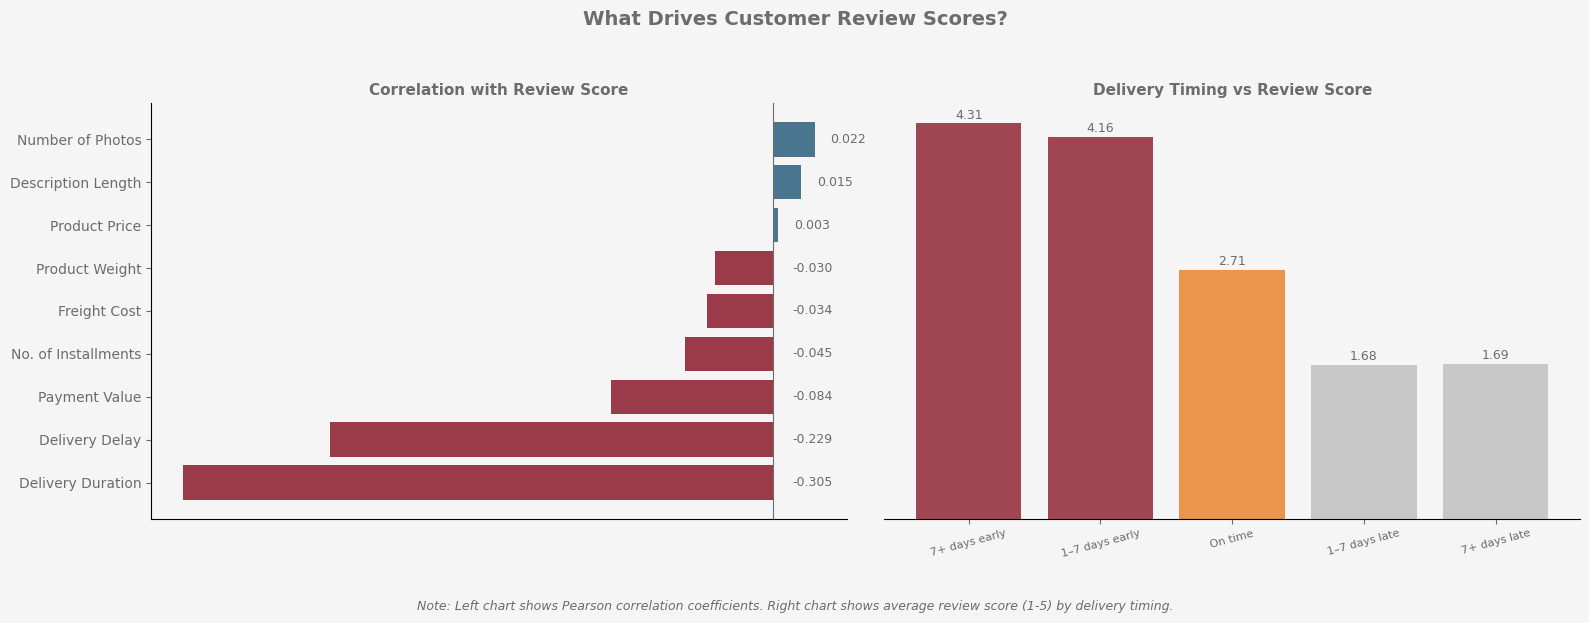

In [357]:
# Four .merge() calls join different tables into one so we can compare everything together. 
# ".corr()" check which feature affect review scores the most. ".rename()" gives columns cleaner names.
#  pd.cut() puts delivery delays into groups. ".barh()" and .bar() draw the two charts side by side.

analysis = order_items.merge(products, on='product_id') \
    .merge(orders[['order_id', 'order_purchase_timestamp',
                   'order_delivered_customer_date', 'order_estimated_delivery_date']], on='order_id') \
    .merge(reviews[['order_id', 'review_score']], on='order_id') \
    .merge(payments.groupby('order_id').agg(
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum')), on='order_id')

analysis['delivery_days'] = (analysis['order_delivered_customer_date'] - analysis['order_purchase_timestamp']).dt.days
analysis['delay_days'] = (analysis['order_delivered_customer_date'] - analysis['order_estimated_delivery_date']).dt.days

features = ['price', 'freight_value', 'delivery_days', 'delay_days', 'payment_installments',
            'payment_value', 'product_weight_g', 'product_description_lenght', 'product_photos_qty', 'review_score']
correlations = analysis[features].dropna().corr()['review_score'].drop('review_score').sort_values()
corr_renamed = correlations.rename({
    'delivery_days': 'Delivery Duration', 'delay_days': 'Delivery Delay',
    'payment_value': 'Payment Value', 'payment_installments': 'No. of Installments',
    'freight_value': 'Freight Cost', 'product_weight_g': 'Product Weight',
    'price': 'Product Price', 'product_description_lenght': 'Description Length',
    'product_photos_qty': 'Number of Photos'
})

delivered['delay_category'] = pd.cut(delivered['delay_days'],
    bins=[-100, -7, 0, 7, 14, 100],
    labels=['7+ days early', '1–7 days early', 'On time', '1–7 days late', '7+ days late'])
delay_scores = delivered.merge(reviews, on='order_id').groupby('delay_category', observed=True)['review_score'].mean()

fig, (corr_chart, timing_chart) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(bg_color)
fig.suptitle('What Drives Customer Review Scores?', fontsize=14, fontweight='bold', color=text_color)

style_ax(corr_chart)
corr_chart.barh(corr_renamed.index, corr_renamed.values,
         color=[accent_red if v < 0 else accent_blue for v in corr_renamed.values], alpha=0.85)
corr_chart.axvline(0, color=text_color, linewidth=0.8)
corr_chart.set_xticks([])
corr_chart.set_title('Correlation with Review Score', fontsize=11, fontweight='bold', color=text_color)
for i, val in enumerate(corr_renamed.values):
    corr_chart.text(val + 0.008 if val >= 0 else 0.01, i, f'{val:.3f}',
                    va='center', fontsize=9, color=text_color)

style_ax(timing_chart, hide=['top', 'right', 'left'])
timing_chart.bar(range(len(delay_scores)), delay_scores.values,
        color=[accent_red, accent_red, accent_orange, light_grey, light_grey], alpha=0.8)
timing_chart.set_xticks(range(len(delay_scores)))
timing_chart.set_xticklabels(delay_scores.index, fontsize=8, rotation=15)
timing_chart.set_yticks([])
timing_chart.set_title('Delivery Timing vs Review Score', fontsize=11, fontweight='bold', color=text_color)
for i, val in enumerate(delay_scores.values):
    timing_chart.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=9, color=text_color)

fig.text(0.5, -0.02, 'Note: Left chart shows Pearson correlation coefficients. Right chart shows average review score (1-5) by delivery timing.',
         ha='center', fontsize=9, fontstyle='italic', color=text_color)
plt.tight_layout(rect=[0, 0.04, 1, 0.94])
plt.show()

In this step, the aim was to demonstrate the correlations. For this purpose, a horizontal bar chart was used. It clearly shows which factors have negative or positive effects. The grouped bar chart next to it was chosen to show how review scores change across delivery timing categories. Delivery duration and delay have the strongest negative correlation with review scores. Price, description length, and photo count have almost no effect. Orders arriving 7 and more days early average 4.3 stars. On the other hand customers give 2.2 for those 7 and more days late. Investing in faster and more reliable delivery will improve customer satisfaction far more than improving product listings.

The correlation values are relatively small in absolute terms, which means delivery is not the only factor, but among the measured variables it has the clearest relationship with customer satisfaction.

### Phase 3: Growth Strategy

#### 3.8 What characteristics define top-performing sellers?

Understanding revenue concentration among sellers guides marketplace growth strategy. If revenue depends on a few sellers, the company must focus on recruiting and retaining them.

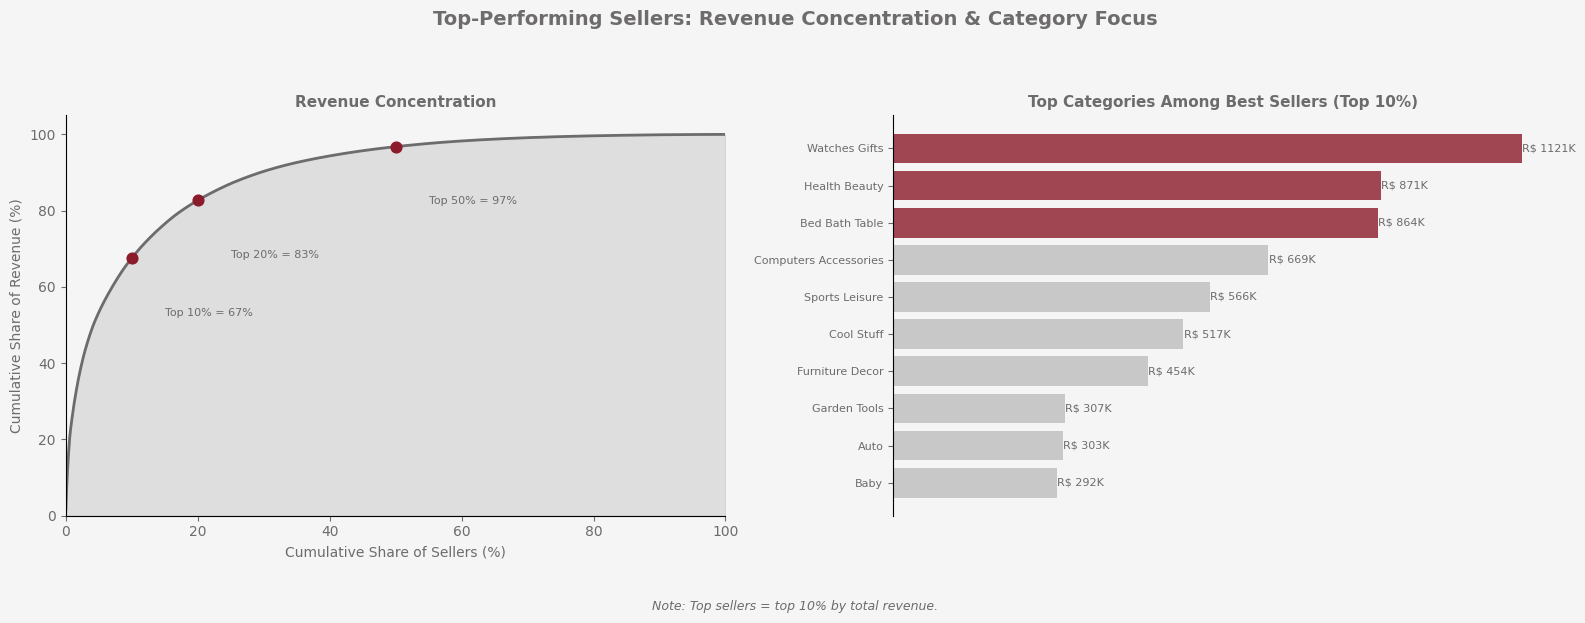

In [358]:
# Total revenue of  seller is computed and sorted. A running total shows how revenue increases among sellers. 
# Product categories are established according to the top 10% of sellers.

seller_revenue = order_items.groupby('seller_id')['price'].sum().sort_values(ascending=False)
seller_cum_percent = seller_revenue.cumsum() / seller_revenue.sum() * 100
seller_rank_percent  = np.arange(1, len(seller_revenue) + 1) / len(seller_revenue) * 100

top_sellers = seller_revenue.head(int(len(seller_revenue) * 0.1)).index
top_categories = order_items[order_items['seller_id'].isin(top_sellers)] \
    .merge(products[['product_id', 'product_category_name_english']], on='product_id') \
    .groupby('product_category_name_english')['price'].sum() \
    .sort_values(ascending=False).head(10)

fig, (concentration_chart, category_chart) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(bg_color)
fig.suptitle('Top-Performing Sellers: Revenue Concentration & Category Focus', fontsize=14, fontweight='bold', color=text_color)

concentration_chart.plot(seller_rank_percent, seller_cum_percent.values, color=text_color, linewidth=2)
concentration_chart.fill_between(seller_rank_percent, seller_cum_percent.values, alpha=0.4, color=light_grey)
for pct in [10, 20, 50]:
    idx = int(len(seller_revenue) * pct / 100) - 1
    share = seller_cum_percent.iloc[idx]
    concentration_chart.scatter(pct, share, color=accent_red, s=60, zorder=5)
    concentration_chart.annotate(f'Top {pct}% = {share:.0f}%', xy=(pct, share), xytext=(pct+5, share-15), fontsize=8, color=text_color)
style_ax(concentration_chart); concentration_chart.set_xlim(0, 100); concentration_chart.set_ylim(0, 105)
concentration_chart.set_xlabel('Cumulative Share of Sellers (%)'); concentration_chart.set_ylabel('Cumulative Share of Revenue (%)')
concentration_chart.set_title('Revenue Concentration', fontsize=11, fontweight='bold', color=text_color)

categories_rev = top_categories[::-1]
category_chart.barh(categories_rev.index, categories_rev.values, color=[light_grey]*7 + [accent_red]*3, alpha=0.8)
for i, val in enumerate(categories_rev.values):
    category_chart.text(val + 500, i, f'R$ {val/1000:.0f}K', va='center', fontsize=8, color=text_color)
category_chart.set_yticklabels([c.replace('_', ' ').title() for c in categories_rev.index], fontsize=8)
style_ax(category_chart, hide=['top', 'right', 'bottom']); category_chart.set_xticks([])
category_chart.set_title('Top Categories Among Best Sellers (Top 10%)', fontsize=11, fontweight='bold', color=text_color)

fig.text(0.5, -0.02, 'Note: Top sellers = top 10% by total revenue.', ha='center', fontsize=9, fontstyle='italic', color=text_color)
plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.show()

To show how much of the total revenue comes from a small group of sellers, a cumulative line chart was used. The horizontal bar chart next to it was chosen to display the top categories clearly. Both of them match the aim of this step. The concentration curve on the left shows that only 10% of sellers generate 67% of all revenue, and the top 50% cover 97%. These top sellers concentrate on Watches Gifts, Health Beauty, and Bed Bath Table, as seen by the bar chart on the right. These groups should be given priority in seller hiring, and a special account management program for top sellers would lower the risk of loss.

#### 3.9 What seasonal demand patterns exist and when is the optimal time to launch?

Knowing which months are busy and which are slow helps to decide when companies want to enter the market. Looking at categories separately also helps plan what to stock and when.

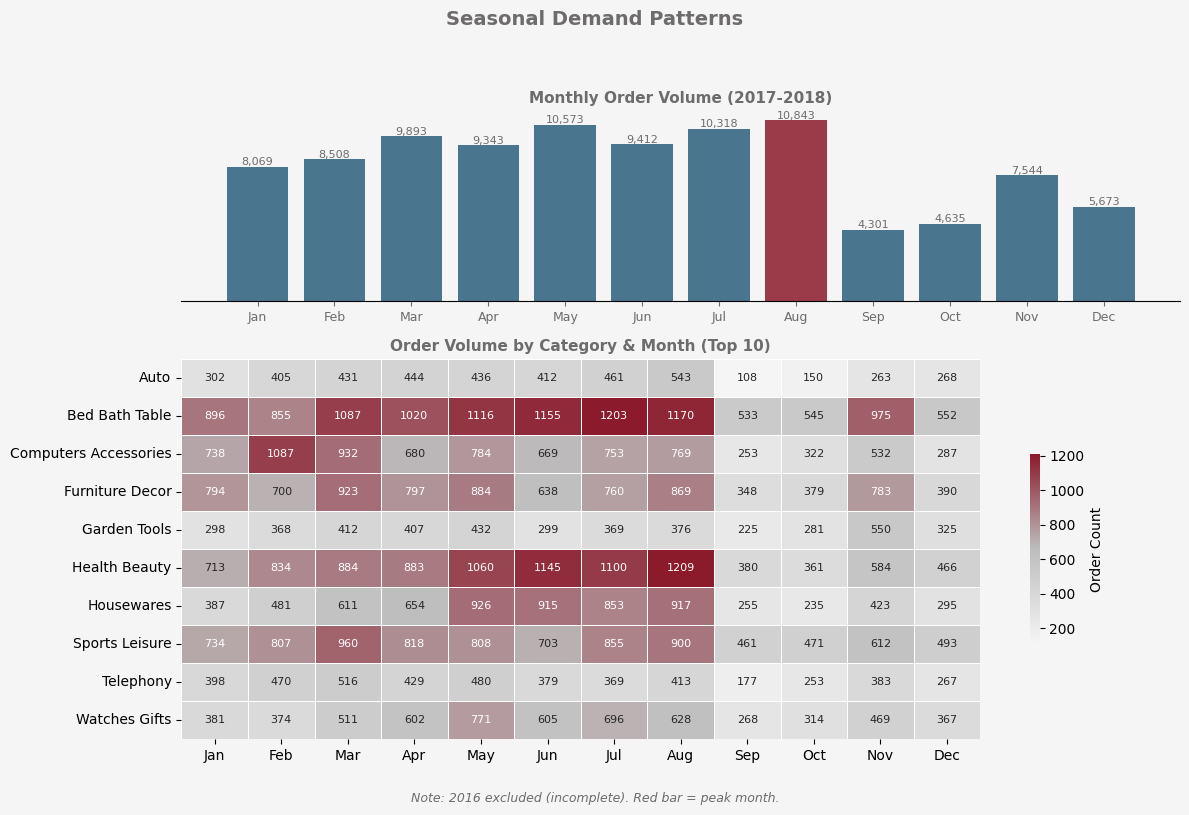

In [359]:
# Order dates are used to get the month and year. 2016 is not complete, 
# therefore only 2017 and 2018 are included. For the heatmap, the grouped data is transformed into a table format.
#  Depending on the number of orders, a specific color scale is used to range from light to dark.

orders['month_num'] = orders['order_purchase_timestamp'].dt.month
orders['year'] = orders['order_purchase_timestamp'].dt.year

category_monthly = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id') \
    .merge(orders[['order_id', 'month_num', 'year']], on='order_id')
category_monthly = category_monthly[category_monthly['year'].isin([2017, 2018])]

top_categories_list = category_monthly.groupby('product_category_name_english')['order_id'].count() \
    .sort_values(ascending=False).head(10).index

heatmap_data = category_monthly[category_monthly['product_category_name_english'].isin(top_categories_list)] \
    .groupby(['product_category_name_english', 'month_num'])['order_id'].count().unstack(fill_value=0)
heatmap_data.index = [i.replace('_', ' ').title() for i in heatmap_data.index]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data.columns = month_labels

monthly_vol = orders[orders['year'].isin([2017, 2018])].groupby('month_num')['order_id'].count()
soft_cmap = LinearSegmentedColormap.from_list('soft', [bg_color, light_grey, accent_red])

fig, (volume_chart, heatmap_chart) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 2]})
fig.patch.set_facecolor(bg_color)
fig.suptitle('Seasonal Demand Patterns', fontsize=14, fontweight='bold', color=text_color)

colors = [accent_red if v == monthly_vol.max() else accent_blue for v in monthly_vol.values]
volume_chart.bar(range(12), monthly_vol.values, color=colors, alpha=0.85)
for i, val in enumerate(monthly_vol.values):
    volume_chart.text(i, val + 100, f'{val:,}', ha='center', fontsize=8, color=text_color)
volume_chart.set_xticks(range(12)); volume_chart.set_xticklabels(month_labels, fontsize=9)
style_ax(volume_chart, hide=['top', 'right', 'left']); volume_chart.set_yticks([])
volume_chart.set_title('Monthly Order Volume (2017-2018)', fontsize=11, fontweight='bold', color=text_color)

sns.heatmap(heatmap_data, ax=heatmap_chart, cmap=soft_cmap, linewidths=0.5, linecolor='white',
            annot=True, fmt='d', annot_kws={'size': 8}, cbar_kws={'shrink': 0.5, 'label': 'Order Count'})
heatmap_chart.set_title('Order Volume by Category & Month (Top 10)', fontsize=11, fontweight='bold', color=text_color)
heatmap_chart.set_xlabel(''); heatmap_chart.set_ylabel('')

fig.text(0.5, -0.01, 'Note: 2016 excluded (incomplete). Red bar = peak month.', ha='center', fontsize=9, fontstyle='italic', color=text_color)

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()


For observing monthly volume, a bar chart was used because it makes peaks and drops easy to spot. A heatmap was used under the bar chart. With this, we can compare multiple categories across months in a single view. The bar chart shows that August has the highest order volume, followed by May and July. Demand drops sharply in September and October. The heatmap below breaks this down by category. Health Beauty and Bed Bath Table show consistent sales during the year, which makes them reliable categories for a market entry. On the other hand, Computers Accessories only spike in certain months, so they need seasonal planning. Based on these observations, the optimal time to enter the market would be between May and August.

# 4. Discussion and Conclusion

Nine business questions structured in three stages were used in this analysis to look at the Brazilian e-commerce market. The objective was to use actual transactional data from more than 100,000 orders to decide whether and how a Turkish e-commerce platform can join the Brazilian market.

## Phase 1: Understanding the Market

The market is geographically concentrated in the Southeast, with São Paulo generating more revenue than the next nine cities combined . 96.9% of customers buy only once, but repeat buyers spend nearly twice as much. Health Beauty, Watches Gifts, and Bed Bath Table are the top three revenue categories . 74% of payments are by credit card, and 67% of those use installments, making installment support a market requirement, not a feature.

## Phase 2: Operational Performance

São Paulo delivers in about 7 days while northern states take 15-25 days. For orders under 50 Brazilian Real, freight exceeds 40% of order value; however, over 200 Brazilian Real, it decreases below 10%, showing a free delivery limit of approximately 100–150 Brazilian Real. Delivery speed is the single biggest driver of review scores: 7 and more days early averages 4.3 stars and 2.2 for 7 and more days late. Price and product descriptions have almost no effect.

## Phase 3: Growth Strategy

A small group of sellers drives most of the revenue. 67% of overall sales come from the top 10%, who mostly sell in the top three categories. The period from May to August is the busiest time in terms of orders. Other categories only reach their maximum sale in specific months. Health, beauty, and bed bath tables sell well during the year.

## Recommendations

Based on these findings, market entry should follow a phased approach:

**Phase 1, Launch:** It makes sense to determine the main states for the growth processes to be carried out as São Paulo, Minas Gerais, and Paraná. These areas have the largest customer base, the fastest delivery times, and the highest customer ratings. Initially, sales need to focus on the Health and Beauty, Watches and Gifts, and Bed Bath Table categories. Also from the beginning, supporting payment options, including credit card installments up to 10 installments and "Boleto," are very important. Another thing to do, more than R$ 100–150, offer free shipping. And finally, schedule the launch between May and August, when demand peaks.

**Phase 2, Expand:** After phase 1 runs smoothly, move into states which have good customer numbers and decent delivery times. These states are, Rio Grande do Sul, Santa Catarina, and Distrito Federal. Then, start adding new product categories based on what the seasonal heatmap showed.

**Phase 3, Scale:** Then enter the Northeast. But not before setting up local logistics partners or warehouses, because delivery in this region is slow and unreliable right now. This is also the right time to launch a loyalty program, since 97% of customers currently buy only once and never come back.


## Overall Conclusion

In summary, Brazil is a feasible market for expansion, but only with a focused and phased approach starting from São Paulo. If looked at customer satisfaction, the findings show that delivery speed is the most impactful factor for customer satisfaction.  Also installment payments are another main functionality that is a market requirement, not an optional feature. Combining these insights with a loyalty program from the beginning would give the company the strongest possible start.

## Strengths and Limitations

This analysis uses real data from over 100,000 orders across all 27 states of Brazil. It covers many areas such as what customers buy, how they pay, how fast deliveries arrive, what makes them happy, which sellers matter most, and when demand is highest. The nine questions follow a logical order. First we understood the market, then we checked how operations work, and finally we looked at growth. Every chart was picked for a reason and explained in the text.

The dataset covers 2016 to 2018, which may seem outdated at first glance. However, this is a natural time gap because companies rarely share their current transactional data due to commercial sensitivity and competitive concerns (Wittes and Kohse, 2017). The data also lacks profit margins and competitor information. Still, the patterns we found, such as geographic concentration, category preferences, and the link between delivery speed and satisfaction, are structural. They change slowly and are very likely still valid. For a more complete picture, the company can combine these findings with current market data before making final decisions.



# 5. References

dLocal (2023) *The power of installment payments in Latin America*. Available at: https://www.dlocal.com/blog/markets-and-consumers/the-power-of-installment-payments-in-latin-america/ (Accessed: 16 May 2026).

eMarketer (2025) *Latin America reclaims its spot as the world's fastest-growing ecommerce market*. Available at: https://www.emarketer.com/content/latin-america-ecommerce-forecast-2025-growth-outlook-argentina-brazil-mexico (Accessed: 13 May 2026).

J.P. Morgan (n.d.) *LATAM's payments landscape is evolving quickly*. Available at: https://www.jpmorgan.com/payments/payments-unbound/magazine/articles/latam-payment-landscape-evolving-quickly (Accessed: 16 May 2026).

Lassance, M. (2024) *squarify: Pure Python implementation of the squarify treemap layout algorithm*. Available at: https://github.com/laserson/squarify (Accessed: 16 May 2026).

Market Data Forecast (2026) *Latin America E-Commerce Market Size, Share, 2034*. Available at: https://www.marketdataforecast.com/market-reports/latin-america-e-commerce-market (Accessed: 13 May 2026).

Olist (2018) *Brazilian E-Commerce Public Dataset by Olist*. Available at: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce (Accessed: 16 May 2026).

Wittes, B. and Kohse, K. (2017) *Understanding Corporate Data Sharing Decisions*. Future of Privacy Forum. Future of Privacy Forum. Available at: https://fpf.org/wp-content/uploads/2017/11/FPF_Data_Sharing_Report_FINAL.pdf (Accessed: 18 June 2026).

